# Window Detection and Permutation ANOVA

## For Best Frans

In [22]:
from analyses.response_window_analysis import run_permutation_anova_by_window
from analyses.spike_count import extract_spike_counts_from_windows
import pandas as pd
from analyses.response_window_finder.threshold_window_detection import compute_timebinned_spikecount_per_neuron, \
    z_score, threshold_and_fill_gap, extract_consecutive_ranges, remove_consecutive_tuples, \
    find_corresponding_values_for_index_ranges
from tqdm import tqdm
import numpy as np
from analyses.data_readers.recording_metadata_reader import RecordingMetadataReader

In [ ]:
# Detect windows for best frans
prelim = RecordingMetadataReader().get_metadata_for_preliminary_analysis()
results = []
bin_size = 0.05  # in sec
rounded_time = np.round(np.arange(bin_size, 3.50, bin_size), 2)
monkey_group = 'Best Frans'
for _, row in tqdm(prelim.iterrows(), total = len(prelim), desc = "Processing each recording day..."):
    round_no = row['Round No.']
    date = str(row['Date'].strftime('%Y-%m-%d'))
    timebin_spikecount_list = compute_timebinned_spikecount_per_neuron(date, round_no, bin_size, monkey_group)
    for _, r in timebin_spikecount_list.iterrows():
        data = r['TotalSpikeCountList']
        neuron = r['NeuronID']
        normalized_data = z_score(data)
        thresh = 0.5
        change_points = threshold_and_fill_gap(normalized_data, thresh)
        windows = extract_consecutive_ranges(change_points)
        filtered_windows = remove_consecutive_tuples(windows)
        time_windows = find_corresponding_values_for_index_ranges(filtered_windows, rounded_time)
        if len(time_windows) > 0:
            for start_time, end_time in time_windows:
                results.append({
                    'NeuronID': neuron,
                    'WindowStart_ms': int(start_time * 1000),
                    'WindowEnd_ms': int(end_time * 1000)
                })


In [ ]:
# Detected windows
bf_results_df = pd.DataFrame(results)
bf_results_df = bf_results_df.sort_values(by=['NeuronID'])
bf_results_df

In [ ]:
# Extract spike counts in the windows
bf_final_df = extract_spike_counts_from_windows(bf_results_df)

In [ ]:
# Run Perm ANOVA on BestFrans
bestfrans_df = bf_final_df[bf_final_df['MonkeyGroup'] == 'Best Frans']
bf_perm_results, bf_sig_results = run_permutation_anova_by_window(bestfrans_df,
                                category_col='MonkeyName',
                                neuron_col='NeuronID',
                                count_col='SpikeCount',
                                window_start_col='WindowStart_ms',
                                window_end_col='WindowEnd_ms',
                                n_permutations=1000,
                                alpha=0.05,
                                plot=False)

In [ ]:
bf_sig_results

In [ ]:
bf_sig_results[['Date', 'Round No.', 'Cell']] = bf_sig_results['NeuronID'].str.split('_', n=2, expand=True)
bf_sig_results['Time Window'] = list(zip(bf_sig_results['WindowStart_ms'], bf_sig_results['WindowEnd_ms']))
bf_sig_results.head() # --- save this and share with Ed !!

In [ ]:
bf_sig_results.to_excel('bestfrans_panova_passed_cells_after_window_detection_updated.xlsx', index=False)

In [ ]:
# Get spike counts anova passed windows
bf_spike_count_for_sig_windows_anova_passed = extract_spike_counts_from_windows(bf_sig_results)

In [ ]:
bf_spike_count = bf_spike_count_for_sig_windows_anova_passed.copy()
bf_spike_count.head()

In [ ]:
bf_spike_count[['Location','Date', 'Round No.', 'Cell']] = bf_spike_count['NeuronID'].str.split('_', n=3, expand=True)
bf_spike_count['Time Window'] = list(zip(bf_spike_count['WindowStart_ms'], bf_spike_count['WindowEnd_ms']))
bf_spike_count.head()

In [ ]:
group_cols = ['Date', 'Round No.', 'Cell', 'Time Window','MonkeyName']
bf_spike_count['Date'] = bf_spike_count['Date'].astype(str)
bf_grouped_df = bf_spike_count.groupby(group_cols)['SpikeCount'].apply(list).reset_index()
bf_final_spike_count_df = bf_grouped_df.pivot(
    index=['Date', 'Round No.', 'Cell', 'Time Window'],
    columns='MonkeyName',
    values='SpikeCount'
).reset_index()
print(bf_final_spike_count_df) # -- save this and share with Ed!!

In [ ]:
bf_final_spike_count_df.to_excel('bestfrans_spike_counts_for_all_panova_passed_time_windowed_updated.xlsx', index=False)

### For Zombies

In [ ]:
# Detect windows for zombies
prelim = RecordingMetadataReader().get_metadata_for_preliminary_analysis()
results = []
bin_size = 0.05  # in sec
rounded_time = np.round(np.arange(bin_size, 3.50, bin_size), 2)
monkey_group = 'Zombies'
for _, row in tqdm(prelim.iterrows(), total = len(prelim), desc = "Processing each recording day..."):
    round_no = row['Round No.']
    date = str(row['Date'].strftime('%Y-%m-%d'))
    timebin_spikecount_list = compute_timebinned_spikecount_per_neuron(date, round_no, bin_size, monkey_group)
    for _, r in timebin_spikecount_list.iterrows():
        data = r['TotalSpikeCountList']
        neuron = r['NeuronID']
        normalized_data = z_score(data)
        thresh = 0.5
        change_points = threshold_and_fill_gap(normalized_data, thresh)
        windows = extract_consecutive_ranges(change_points)
        filtered_windows = remove_consecutive_tuples(windows)
        time_windows = find_corresponding_values_for_index_ranges(filtered_windows, rounded_time)
        if len(time_windows) > 0:
            for start_time, end_time in time_windows:
                results.append({
                    'NeuronID': neuron,
                    'WindowStart_ms': int(start_time * 1000),
                    'WindowEnd_ms': int(end_time * 1000)
                })


In [ ]:
# Detected windows
zombies_results_df = pd.DataFrame(results)
zombies_results_df = zombies_results_df.sort_values(by=['NeuronID'])
zombies_results_df.head()

In [ ]:
# Extract spike counts in the windows
zombies_extracted_spikes_df = extract_spike_counts_from_windows(zombies_results_df)

In [ ]:
# Run Perm ANOVA on BestFrans
zombies_df = zombies_extracted_spikes_df[zombies_extracted_spikes_df['MonkeyGroup'] == monkey_group]
_, zom_sig_results = run_permutation_anova_by_window(zombies_df,
                                category_col='MonkeyName',
                                neuron_col='NeuronID',
                                count_col='SpikeCount',
                                window_start_col='WindowStart_ms',
                                window_end_col='WindowEnd_ms',
                                n_permutations=1000,
                                alpha=0.05,
                                plot=False)

In [ ]:
zom_sig_results.head()

In [ ]:
zom_sig_copy= zom_sig_results.copy()
zom_sig_copy[['Date', 'Round No.', 'Cell']] = zom_sig_results['NeuronID'].str.split('_', n=2, expand=True)
zom_sig_copy['Time Window'] = list(zip(zom_sig_copy['WindowStart_ms'], zom_sig_copy['WindowEnd_ms']))
zom_sig_copy.head() # --- save this and share with Ed !!

In [ ]:
zom_sig_copy.to_excel('zombies_panova_passed_cells_after_window_detection_updated.xlsx', index=False)
print('Done!')

In [ ]:
# Get spike counts anova passed windows
zom_spike_count_for_sig_windows_anova_passed = extract_spike_counts_from_windows(zom_sig_copy)

In [ ]:
zom_spike_count = zom_spike_count_for_sig_windows_anova_passed.copy()
zom_spike_count.head()

In [ ]:
zom_spike_count[['Location','Date', 'Round No.', 'Cell']] = zom_spike_count['NeuronID'].str.split('_', n=3, expand=True)
zom_spike_count['Time Window'] = list(zip(zom_spike_count['WindowStart_ms'], zom_spike_count['WindowEnd_ms']))
zom_spike_count.head()

In [ ]:
zom_spike_count.head()
group_cols = ['Date', 'Round No.', 'Cell', 'Time Window', 'MonkeyName']
zom_spike_count['Date'] = zom_spike_count['Date'].astype(str)
zom_grouped_df = zom_spike_count.groupby(group_cols)['SpikeCount'].apply(list).reset_index()
zom_final_spike_count_df = zom_grouped_df.pivot(
    index=['Date', 'Round No.', 'Cell', 'Time Window'],
    columns='MonkeyName',
    values='SpikeCount'
).reset_index()
print(zom_final_spike_count_df.head())  # -- save this and share with Ed!!

In [ ]:
zom_final_spike_count_df.to_excel('zombies_spike_counts_for_all_panova_passed_time_windowed_updated.xlsx', index=False)

# Counts Cells for Grants -- ANOVA passed cells

In [ ]:
sig_cells = pd.read_excel('/home/connorlab/Documents/GitHub/Julie/Cortana/Ed and ANOVA/zombies_all_anova_passed_cells--used for grant.xlsx')

In [ ]:
sig_cells

In [ ]:
prelim = RecordingMetadataReader().get_metadata_for_preliminary_analysis()
prelim

In [ ]:
# sig_cells의 조합 중 prelim에 없는 것
merged_df = pd.merge(sig_cells, prelim, on=['Date','Round No.'], how='left', indicator=True)

In [ ]:
merged_df

In [ ]:
merged_df['NeuronID'] = (
        merged_df['Location'].astype(str) + "_" +
        merged_df['Date'].astype(str) + "_" +
        merged_df['Round No.'].astype(str) + "_" +
        merged_df['Cell'].astype(str)
)

In [ ]:
unique_neurons = merged_df['NeuronID'].unique()
print(len(unique_neurons))

In [ ]:
neuron_list= list(unique_neurons)
amg_neuron_count = sum(1 for neuron in neuron_list if neuron.startswith('Amygdala'))
er_neuron_count = sum(1 for neuron in neuron_list if neuron.startswith('ER'))
uncertain_neuron_count = sum(1 for neuron in neuron_list if neuron.startswith('na'))
print(amg_neuron_count)
print(er_neuron_count)
print(uncertain_neuron_count)

In [ ]:
neuron_list

In [6]:
bf_cells = pd.read_excel('/home/connorlab/Documents/GitHub/Julie/Cortana/Ed and ANOVA/bestfrans_anova_passed_cells_old -- used for grant.xlsx')
bf_cells

,Unnamed: 0,F-statistic,p-value,Date,Round No.,Cell,Time Window
0,47,3.282644,0.027,2023-09-26,3,Channel.C_027_Unit 1,"(250, 450)"
1,89,3.152212,0.016,2023-09-29,3,Channel.C_029_Unit 1,"(400, 550)"
2,134,2.706827,0.037,2023-10-03,4,Channel.C_010_Unit 1,"(100, 650)"
3,148,3.512962,0.017,2023-10-03,4,Channel.C_025_Unit 2,"(850, 950)"
4,171,2.686364,0.038,2023-10-04,2,Channel.C_009_Unit 1,"(200, 400)"
5,174,2.858108,0.012,2023-10-04,2,Channel.C_009_Unit 2,"(1300, 1500)"
6,191,5.344846,0.001,2023-10-04,3,Channel.C_009_Unit 1,"(150, 350)"
7,299,2.169755,0.000,2023-10-09,3,Channel.C_024,"(700, 950)"
8,308,2.597494,0.043,2023-10-10,2,Channel.C_010,"(300, 600)"
9,317,2.350410,0.047,2023-10-10,2,Channel.C_022,"(950, 1100)"


## From here, just read the files (csv) that's already been generated

In [2]:
from collections import Counter
import csv

with open('../Cortana/Ed and ANOVA/used_for_R01/zombies_neuron_list_with_location.csv', 'r') as f:
    zombies_neuron_list = [line.strip() for line in f if line.strip()]
zombies_neuron_list

['Amygdala_2023-09-26_1_Channel.C_027_Unit 1',
 'Amygdala_2023-09-26_2_Channel.C_011_Unit 1',
 'Amygdala_2023-09-26_2_Channel.C_020',
 'Amygdala_2023-09-26_3_Channel.C_002_Unit 1',
 'Amygdala_2023-09-26_3_Channel.C_007_Unit 2',
 'Amygdala_2023-09-26_3_Channel.C_027_Unit 2',
 'Amygdala_2023-10-03_3_Channel.C_006_Unit 1',
 'Amygdala_2023-10-03_3_Channel.C_013_Unit 1',
 'Amygdala_2023-10-03_3_Channel.C_026_Unit 1',
 'Amygdala_2023-10-03_4_Channel.C_006',
 'Amygdala_2023-10-03_4_Channel.C_010_Unit 2',
 'Amygdala_2023-10-03_4_Channel.C_026',
 'Amygdala_2023-10-04_1_Channel.C_004_Unit 1',
 'Amygdala_2023-10-04_1_Channel.C_019_Unit 3',
 'Amygdala_2023-10-04_2_Channel.C_018_Unit 1',
 'Amygdala_2023-10-04_2_Channel.C_020_Unit 2',
 'Amygdala_2023-10-04_3_Channel.C_002_Unit 1',
 'Amygdala_2023-10-04_3_Channel.C_004_Unit 2',
 'Amygdala_2023-10-04_3_Channel.C_009_Unit 1',
 'Amygdala_2023-10-04_3_Channel.C_009_Unit 3',
 'Amygdala_2023-10-04_4_Channel.C_021_Unit 2',
 'Amygdala_2023-10-04_4_Channel.C_

In [3]:
print(len(zombies_neuron_list))
amg_neuron_count = sum(1 for neuron in zombies_neuron_list if neuron.startswith('Amygdala'))
er_neuron_count = sum(1 for neuron in zombies_neuron_list if neuron.startswith('ER'))
uncertain_neuron_count = sum(1 for neuron in zombies_neuron_list if neuron.startswith('na'))
print(amg_neuron_count)
print(er_neuron_count)
print(uncertain_neuron_count)

56
36
20
0


In [4]:
import pandas as pd
# Extract Date and Round No
date_rounds = [(s.split('_')[1], s.split('_')[2]) for s in zombies_neuron_list]

# Count occurrences
counter = Counter(date_rounds)

# Convert to DataFrame
zombies_round_count_df = pd.DataFrame([
    {'Date': date, 'Round No.': round_no, 'Zombies': count}
    for (date, round_no), count in counter.items()
])

# Optional: sort by date and round
zombies_round_count_df = zombies_round_count_df.sort_values(by=['Date', 'Round No.']).reset_index(drop=True)

print(zombies_round_count_df)

          Date Round No.  Zombies
0   2023-09-26         1        1
1   2023-09-26         2        2
2   2023-09-26         3        3
3   2023-10-03         3        3
4   2023-10-03         4        3
5   2023-10-04         1        2
6   2023-10-04         2        2
7   2023-10-04         3        4
8   2023-10-04         4        3
9   2023-10-05         1        2
10  2023-10-05         2        3
11  2023-10-09         3        1
12  2023-10-10         2        3
13  2023-10-11         1        2
14  2023-10-11         3        2
15  2023-10-24         2        1
16  2023-10-27         3        2
17  2023-10-27         4        2
18  2023-11-20         1        1
19  2023-11-20         2        1
20  2023-11-25         1        2
21  2023-11-25         3        1
22  2023-11-28         3        1
23  2023-11-28         4        1
24  2023-12-05         4        1
25  2023-12-14         1        2
26  2023-12-14         4        2
27  2023-12-18         2        1
28  2023-12-18

In [5]:
with open('../Cortana/Ed and ANOVA/used_for_R01/bestfrans_neuron_list_with_location.csv', 'r') as f:
    bf_neuron_list = [line.strip() for line in f if line.strip()]
bf_neuron_list

['Amygdala_2023-09-26_3_Channel.C_027_Unit 1',
 'Amygdala_2023-09-29_3_Channel.C_029_Unit 1',
 'Amygdala_2023-10-03_4_Channel.C_010_Unit 1',
 'Amygdala_2023-10-03_4_Channel.C_025_Unit 2',
 'Amygdala_2023-10-04_2_Channel.C_009_Unit 1',
 'Amygdala_2023-10-04_2_Channel.C_009_Unit 2',
 'Amygdala_2023-10-04_3_Channel.C_009_Unit 1',
 'Amygdala_2023-10-09_3_Channel.C_024',
 'Amygdala_2023-10-10_2_Channel.C_010',
 'Amygdala_2023-10-10_2_Channel.C_022',
 'Amygdala_2023-10-10_3_Channel.C_022',
 'Amygdala_2023-10-11_3_Channel.C_024',
 'ER_2023-10-27_3_Channel.C_015',
 'ER_2023-11-20_2_Channel.C_009',
 'ER_2023-11-22_2_Channel.C_009',
 'ER_2023-11-22_3_Channel.C_027',
 'ER_2023-11-22_3_Channel.C_028',
 'ER_2023-11-25_1_Channel.C_009',
 'ER_2023-11-25_1_Channel.C_017',
 'ER_2023-11-25_2_Channel.C_016',
 'ER_2023-11-25_3_Channel.C_018',
 'ER_2023-11-27_3_Channel.C_002',
 'ER_2023-11-27_3_Channel.C_017',
 'ER_2023-11-28_3_Channel.C_009',
 'ER_2023-11-28_4_Channel.C_015',
 'ER_2023-12-11_4_Channel.C_0

In [6]:
amg_neuron_count = sum(1 for neuron in bf_neuron_list if neuron.startswith('Amygdala'))
er_neuron_count = sum(1 for neuron in bf_neuron_list if neuron.startswith('ER'))
uncertain_neuron_count = sum(1 for neuron in bf_neuron_list if neuron.startswith('na'))
print(amg_neuron_count)
print(er_neuron_count)
print(uncertain_neuron_count)

12
22
0


In [7]:
bf_neuron_list

['Amygdala_2023-09-26_3_Channel.C_027_Unit 1',
 'Amygdala_2023-09-29_3_Channel.C_029_Unit 1',
 'Amygdala_2023-10-03_4_Channel.C_010_Unit 1',
 'Amygdala_2023-10-03_4_Channel.C_025_Unit 2',
 'Amygdala_2023-10-04_2_Channel.C_009_Unit 1',
 'Amygdala_2023-10-04_2_Channel.C_009_Unit 2',
 'Amygdala_2023-10-04_3_Channel.C_009_Unit 1',
 'Amygdala_2023-10-09_3_Channel.C_024',
 'Amygdala_2023-10-10_2_Channel.C_010',
 'Amygdala_2023-10-10_2_Channel.C_022',
 'Amygdala_2023-10-10_3_Channel.C_022',
 'Amygdala_2023-10-11_3_Channel.C_024',
 'ER_2023-10-27_3_Channel.C_015',
 'ER_2023-11-20_2_Channel.C_009',
 'ER_2023-11-22_2_Channel.C_009',
 'ER_2023-11-22_3_Channel.C_027',
 'ER_2023-11-22_3_Channel.C_028',
 'ER_2023-11-25_1_Channel.C_009',
 'ER_2023-11-25_1_Channel.C_017',
 'ER_2023-11-25_2_Channel.C_016',
 'ER_2023-11-25_3_Channel.C_018',
 'ER_2023-11-27_3_Channel.C_002',
 'ER_2023-11-27_3_Channel.C_017',
 'ER_2023-11-28_3_Channel.C_009',
 'ER_2023-11-28_4_Channel.C_015',
 'ER_2023-12-11_4_Channel.C_0

In [8]:
date_rounds = [(s.split('_')[1], s.split('_')[2]) for s in bf_neuron_list]

# Count occurrences
counter = Counter(date_rounds)

# Convert to DataFrame
bf_round_count_df = pd.DataFrame([
    {'Date': date, 'Round No.': round_no, 'BestFrans': count}
    for (date, round_no), count in counter.items()
])

# Optional: sort by date and round
bf_round_count_df = bf_round_count_df.sort_values(by=['Date', 'Round No.']).reset_index(drop=True)

print(bf_round_count_df)

          Date Round No.  BestFrans
0   2023-09-26         3          1
1   2023-09-29         3          1
2   2023-10-03         4          2
3   2023-10-04         2          2
4   2023-10-04         3          1
5   2023-10-09         3          1
6   2023-10-10         2          2
7   2023-10-10         3          1
8   2023-10-11         3          1
9   2023-10-27         3          1
10  2023-11-20         2          1
11  2023-11-22         2          1
12  2023-11-22         3          2
13  2023-11-25         1          2
14  2023-11-25         2          1
15  2023-11-25         3          1
16  2023-11-27         3          2
17  2023-11-28         3          1
18  2023-11-28         4          1
19  2023-12-11         4          1
20  2023-12-14         1          1
21  2023-12-14         4          1
22  2023-12-18         2          4
23  2023-12-18         3          2


In [9]:
round_count_merged = pd.merge(bf_round_count_df, zombies_round_count_df, on=['Date', 'Round No.'], how='outer')
round_count_merged.fillna(0, inplace=True)
round_count_merged[['BestFrans', 'Zombies']] = round_count_merged[['BestFrans', 'Zombies']].astype(int)
round_count_merged

,Date,Round No.,BestFrans,Zombies
0,2023-09-26,3,1,3
1,2023-09-29,3,1,0
2,2023-10-03,4,2,3
3,2023-10-04,2,2,2
4,2023-10-04,3,1,4
5,2023-10-09,3,1,1
6,2023-10-10,2,2,3
7,2023-10-10,3,1,0
8,2023-10-11,3,1,2
9,2023-10-27,3,1,2


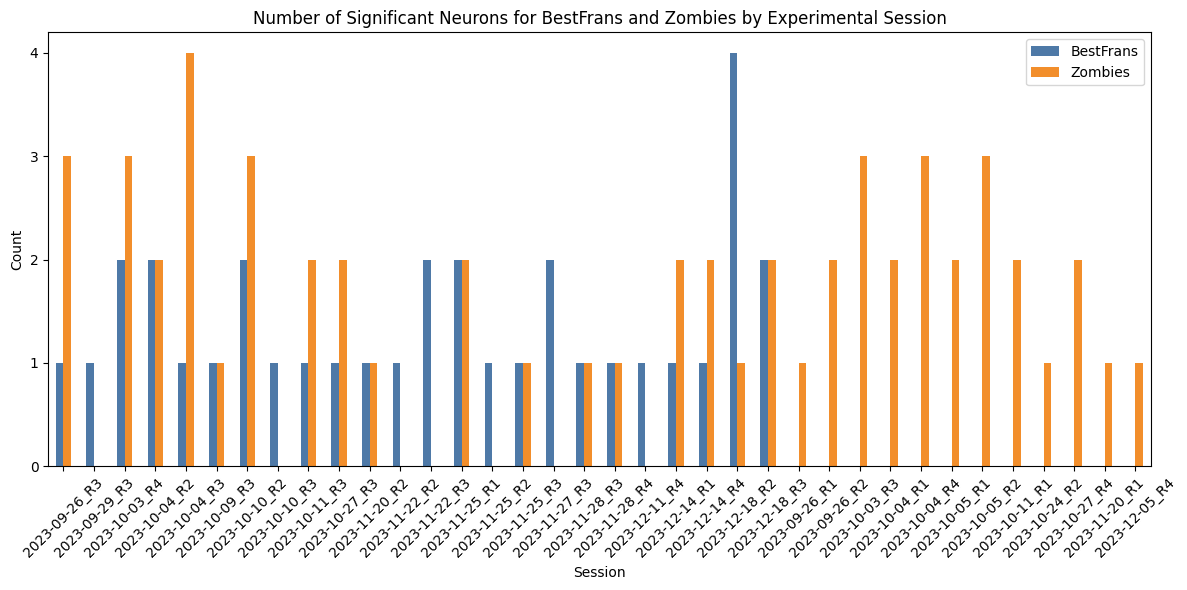

In [10]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
%matplotlib inline
round_count_merged['Session'] = round_count_merged['Date'] + '_R' + round_count_merged['Round No.'].astype(str)
df_plot = round_count_merged.set_index('Session')[['BestFrans', 'Zombies']]

df_plot.plot(kind='bar', figsize=(12, 6), color=['#4e79a7', '#f28e2b'])
plt.ylabel('Count')
plt.title('Number of Significant Neurons for BestFrans and Zombies by Experimental Session')
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout()
plt.show()


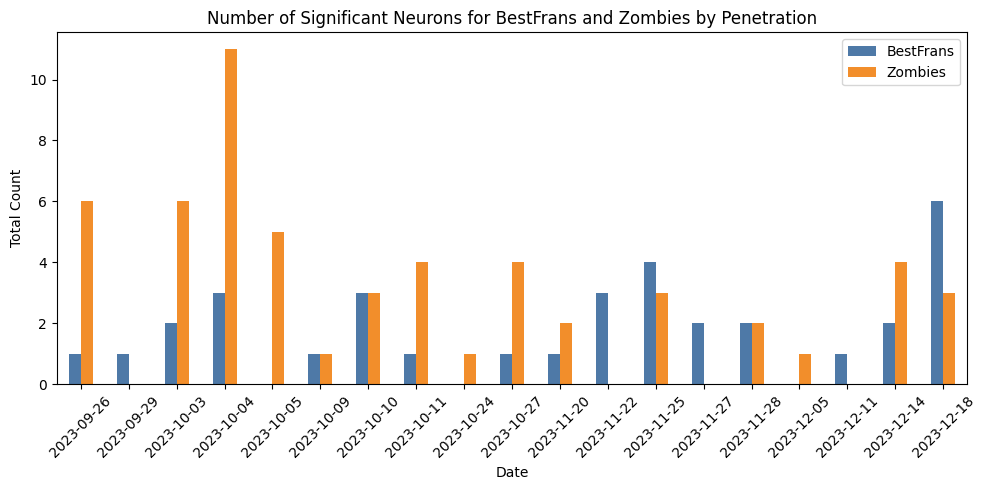

In [11]:
# Date 기준으로 합산
df_grouped = round_count_merged.groupby('Date')[['BestFrans', 'Zombies']].sum().reset_index()
df_grouped[['BestFrans', 'Zombies']] = df_grouped[['BestFrans', 'Zombies']].astype(int)
df_grouped.set_index('Date').plot(
    kind='bar',
    figsize=(10, 5),
    color=['#4e79a7', '#f28e2b']  # BestFrans, Zombies
)

plt.ylabel('Total Count')
plt.title('Number of Significant Neurons for BestFrans and Zombies by Penetration')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [13]:
from analyses.data_readers.recording_metadata_reader import RecordingMetadataReader
prelim = RecordingMetadataReader().get_metadata_for_preliminary_analysis()
prelim['Date'] = prelim['Date'].apply(lambda x: x.strftime('%Y-%m-%d'))
prelim['Round No.'] = prelim['Round No.'].astype(int)
round_count_merged['Round No.'] = round_count_merged['Round No.'].astype(int)
all_rounds = pd.merge(round_count_merged,prelim, on=['Date','Round No.'], how='right', indicator=True)
all_rounds['Session'] = all_rounds['Date'] + '_R' + all_rounds['Round No.'].astype(str)

In [14]:
all_rounds[['BestFrans', 'Zombies']] = all_rounds[['BestFrans', 'Zombies']].fillna(0)

In [15]:
all_rounds[['BestFrans', 'Zombies']] = all_rounds[['BestFrans', 'Zombies']].astype(int)

In [16]:
all_rounds

,Date,Round No.,BestFrans,Zombies,Session,Location,_merge
0,2023-09-26,1,0,1,2023-09-26_R1,Amygdala,both
1,2023-09-26,2,0,2,2023-09-26_R2,Amygdala,both
2,2023-09-26,3,1,3,2023-09-26_R3,Amygdala,both
3,2023-09-28,1,0,0,2023-09-28_R1,Amygdala,right_only
4,2023-09-29,2,0,0,2023-09-29_R2,Amygdala,right_only
5,2023-09-29,3,1,0,2023-09-29_R3,Amygdala,both
6,2023-09-29,4,0,0,2023-09-29_R4,Amygdala,right_only
7,2023-10-03,1,0,0,2023-10-03_R1,Amygdala,right_only
8,2023-10-03,3,0,3,2023-10-03_R3,Amygdala,both
9,2023-10-03,4,2,3,2023-10-03_R4,Amygdala,both


In [17]:

round_count_merged.to_csv('num_of_sig_neurons_by_session.csv', index=False)

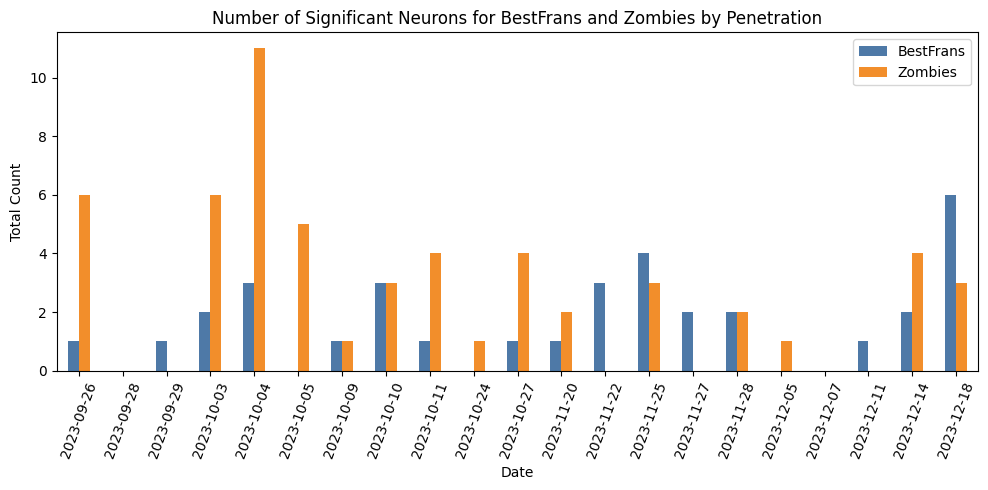

In [24]:
# Date 기준으로 합산
%matplotlib inline
df_grouped = all_rounds.groupby('Date')[['BestFrans', 'Zombies']].sum().reset_index()
df_grouped[['BestFrans', 'Zombies']] = df_grouped[['BestFrans', 'Zombies']].astype(int)
df_grouped.set_index('Date').plot(
    kind='bar',
    figsize=(10, 5),
    color=['#4e79a7', '#f28e2b']  # BestFrans, Zombies
)

plt.ylabel('Total Count')
plt.title('Number of Significant Neurons for BestFrans and Zombies by Penetration')
plt.xticks(rotation=70)
plt.tight_layout()
plt.show()


In [20]:
all_rounds.to_csv('all_rounds_with_num_of_sig_neurons.csv', index=False)